In [2]:
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric -f https://data.pyg.org/whl/torch-$(python -c 'import torch; print(torch.__version__)').html -q
!pip install torchmetrics -q
!pip install thop -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# PyTorch Geometric imports
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool, knn_graph, BatchNorm
from torch_geometric.data import Data, Batch
from torchvision.models import vit_b_16, ViT_B_16_Weights

# Metrics and Logging
from torchmetrics.classification import MulticlassAUROC
from thop import profile # <-- CORRECTED IMPORT
import csv
import os

import torchvision
import torchvision.transforms as transforms
import numpy as np
from tqdm.notebook import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
class vit_knn_gcn(nn.Module):
    def __init__(self, patch_size, depth, dim=128, k=9, num_classes=10):
        super().__init__()
        self.patch_size=patch_size
        self.dim=dim
        self.k=k
        weights = ViT_B_16_Weights.IMAGENET1K_V1
        self.vit = vit_b_16(weights=weights)
        self.embed_dim = 768
        self.depth = depth
        
        self.conv1 = GCNConv(self.embed_dim, dim*2)
        self.conv2 = GCNConv(dim*2, dim)
        self.head = nn.Sequential(
            nn.Linear(dim, dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(dim, num_classes)
        )
        self.dropout = nn.Dropout(0.1)
        self.bn1 = BatchNorm(dim*2)
        self.bn2 = BatchNorm(dim)

    def forward(self, img):
        with torch.no_grad():
            x = self.vit.conv_proj(img)
            x = x.flatten(2).transpose(1, 2)
            n = x.shape[0]
            batch_class_token = self.vit.class_token.expand(n, -1, -1)
            x = torch.cat([batch_class_token, x], dim=1)
            x = x + self.vit.encoder.pos_embedding
            for i in range(self.depth):
                x = self.vit.encoder.layers[i](x)
            x = self.vit.encoder.ln(x)
        x = x[:, 1:]
        B, N, C = x.shape
        x_flat = x.reshape(-1, C)
        batch_vec = torch.arange(B, device=x.device).repeat_interleave(N)
        edge_index = knn_graph(x_flat, k=self.k, batch=batch_vec, loop=True)
        h = self.conv1(x_flat, edge_index)
        h = self.bn1(h)
        h = F.relu(h)
        h = F.dropout(h, p=0.2, training=self.training)
        
        h=self.conv2(h, edge_index)
        h = self.bn2(h)
        h = F.relu(h)
        
        h_batch = global_mean_pool(h, batch_vec)
        out = self.head(h_batch)
        return out

results_filename = 'diagnostics_vit_knn_gcn.csv'
with open(results_filename, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(["epoch", "train_loss", "train_acc", "test_loss", "test_acc", "test_auc", "avg_flops_g"])

In [4]:
def train_loop(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for img, label in loader:
        img, label = img.to(device), label.to(device)
        optimizer.zero_grad()
        output = model(img)
        loss = criterion(output, label)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * img.size(0)
        pred = output.argmax(dim=1)
        correct += (pred==label).sum().item()
        total += img.size(0)
    return total_loss/total, correct/total

@torch.no_grad()
def test_loop(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds = []
    all_labels = []
    for img, label in loader:
        img, label = img.to(device), label.to(device)
        output = model(img)
        loss = criterion(output, label)
        total_loss += loss.item() * img.size(0)
        pred = output.argmax(dim=1)
        correct += (pred==label).sum().item()
        total += img.size(0)
        all_preds.append(F.softmax(output, dim=1))
        all_labels.append(label)
    all_preds = torch.cat(all_preds, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    return total_loss/total, correct/total, all_preds, all_labels
    

In [5]:
batch_size = 32
patch_size = 8
node_feature_dim = 3*patch_size*patch_size
hidden_dim = 128
k=15
epochs = 15

model = vit_knn_gcn(patch_size=patch_size, depth=2, dim=hidden_dim, k=k, num_classes=10).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
criterion = nn.CrossEntropyLoss()
auroc_metric = MulticlassAUROC(num_classes=10, average="macro", thresholds=None).to(device)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Added Color Jitter
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 216MB/s] 
100%|██████████| 170M/170M [00:03<00:00, 49.9MB/s] 


In [6]:
try:
    batch_data = next(iter(testloader))
    images = batch_data[0].to(device) 
    
    # ViT is heavy, disable verbose to avoid spamming layer info
    macs, params = profile(model, inputs=(images,), verbose=False)
    total_flops_g = macs / 1e9
    avg_flops_g = total_flops_g / batch_size
    print(f"Average FLOPs per image: {avg_flops_g:.4f} GFLOPs")
except Exception as e:
    print(f"FLOPs Error: {e}")
    avg_flops_g = 0
    
best_acc = 0
print("\n--- Starting Training ---")
for epoch in range(epochs):
    train_loss, train_acc = train_loop(model, tqdm(trainloader, desc='Training'), optimizer, criterion)
    test_loss, test_acc, test_preds, test_labels = test_loop(model, tqdm(testloader, desc='Testing'), criterion)
    test_auc = auroc_metric(test_preds, test_labels).item()
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), f'best_gcn_model.pth')
    print(f"\nEpoch {epoch+1}/{epochs} Summary:")
    print(f'  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}')
    print(f'  Test Loss:  {test_loss:.4f} | Test Acc:  {test_acc:.4f} | Test AUC: {test_auc:.4f} | Best Acc: {best_acc:.4f}')
    with open(results_filename, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([
            epoch + 1, train_loss, train_acc, 
            test_loss, test_acc, test_auc, avg_flops_g
        ])

    scheduler.step()
print(f"\n--- Training Complete ---")
print(f"Final best accuracy: {best_acc:.4f}")
print(f"Diagnostics saved to {results_filename}")

Average FLOPs per image: 1.9781 GFLOPs

--- Starting Training ---


Training:   0%|          | 0/1563 [00:00<?, ?it/s]

Testing:   0%|          | 0/313 [00:00<?, ?it/s]


Epoch 1/15 Summary:
  Train Loss: 1.2767 | Train Acc: 0.5400
  Test Loss:  0.9730 | Test Acc:  0.6478 | Test AUC: 0.9453 | Best Acc: 0.6478


Training:   0%|          | 0/1563 [00:00<?, ?it/s]

...

Testing:   0%|          | 0/313 [00:00<?, ?it/s]


Epoch 14/15 Summary:
  Train Loss: 0.6877 | Train Acc: 0.7565
  Test Loss:  0.6368 | Test Acc:  0.7718 | Test AUC: 0.9748 | Best Acc: 0.7735


Training:   0%|          | 0/1563 [00:00<?, ?it/s]

Testing:   0%|          | 0/313 [00:00<?, ?it/s]


Epoch 15/15 Summary:
  Train Loss: 0.6765 | Train Acc: 0.7606
  Test Loss:  0.6331 | Test Acc:  0.7736 | Test AUC: 0.9749 | Best Acc: 0.7736

--- Training Complete ---
Final best accuracy: 0.7736
Diagnostics saved to diagnostics_vit_knn_gcn.csv


📂 Output Directory: /kaggle/working/experiment_results
📦 Moving artifacts...

🎨 Generating Visualizations...


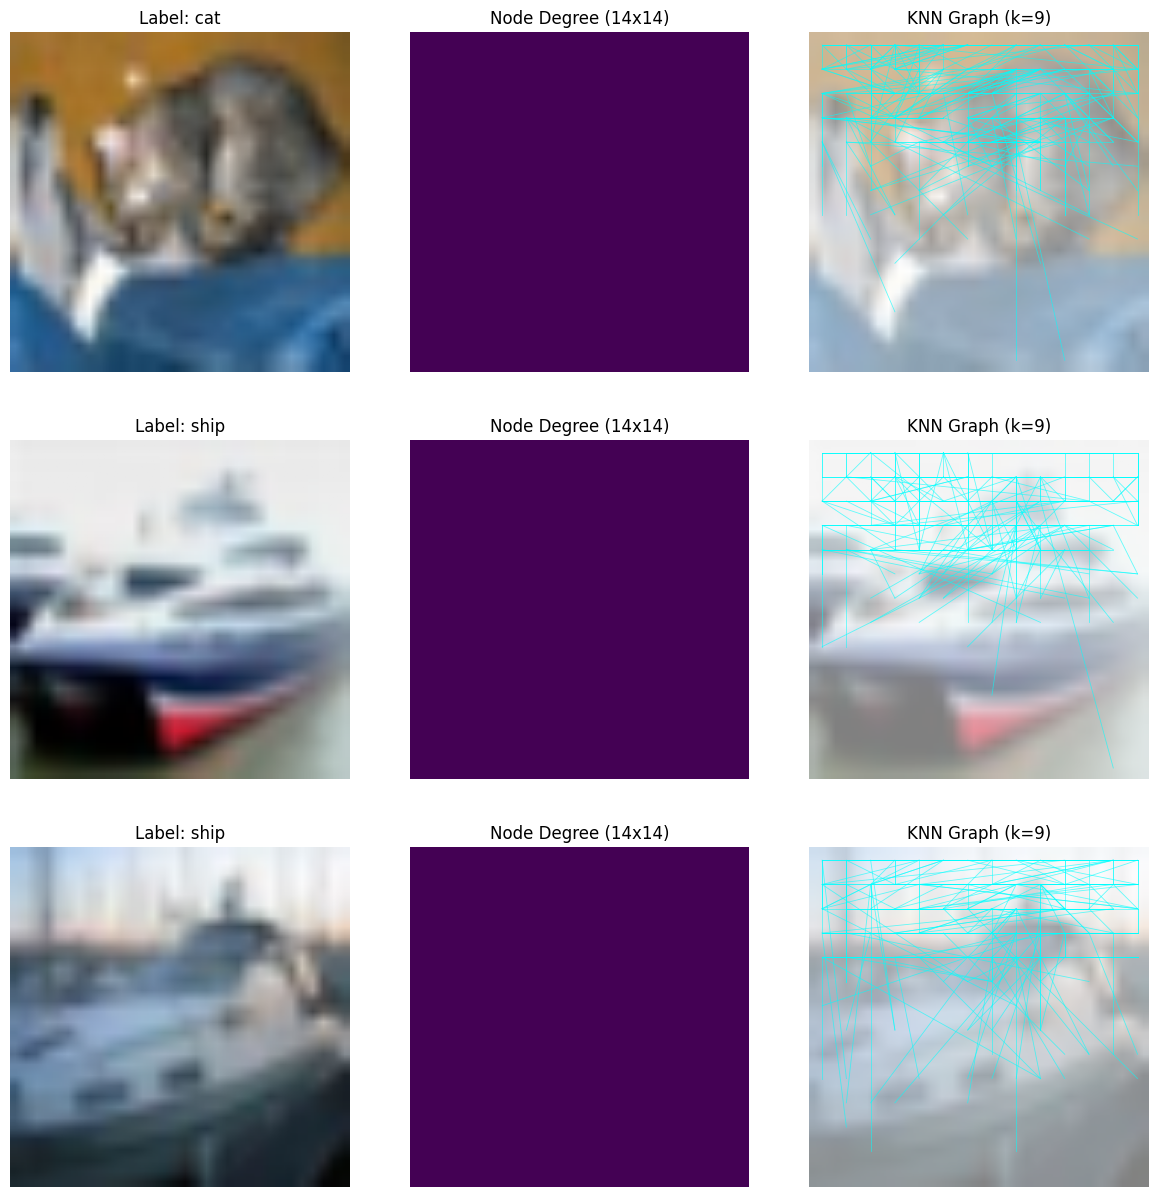

   ✅ Saved plots to /kaggle/working/experiment_results/graph_visualizations.png

🔍 Running Sanity Checks...
✅ Outputs are numeric (No NaNs)
✅ Logits Mean: -2.7644, Std: 4.2671
ℹ️  Predicted Classes in batch: [0, 1, 3, 4, 5, 6, 7, 8, 9]
   ✅ Saved log to /kaggle/working/experiment_results/sanity_check_log.txt

📦 Created zip file: /kaggle/working/experiment_results.zip


In [11]:
import os
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np
from torch_geometric.nn import knn_graph

# --- 1. Kaggle Path Setup ---
BASE_DIR = "/kaggle/working"
OUTPUT_FOLDER = os.path.join(BASE_DIR, "experiment_results")
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
print(f"📂 Output Directory: {OUTPUT_FOLDER}")

# --- 2. Move Artifacts ---
# We check specific filenames that might exist from previous steps
files_to_check = [
    "best_gcn_model.pth", 
    "best_vit_patch_gcn.pth",
    "best_resnet_gcn.pth",
    "diagnostics_vit_patch_gcn.csv",
    "diagnostics_resnet_knn_gcn.csv",
    "diagnostics_vit_knn_gcn.csv"
]

print("📦 Moving artifacts...")
for filename in os.listdir(BASE_DIR):
    if filename in files_to_check and filename != "experiment_results":
        src = os.path.join(BASE_DIR, filename)
        dst = os.path.join(OUTPUT_FOLDER, filename)
        shutil.move(src, dst)
        print(f"   ✅ Moved: {filename}")

# --- 3. Visualization Logic (Corrected) ---
def unnormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(tensor.device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(tensor.device)
    img = tensor * std + mean
    return img.clamp(0, 1)

def save_visualizations(model, loader, save_dir, k=9, num_samples=3):
    print(f"\n🎨 Generating Visualizations...")
    model.eval()
    
    # Get a batch
    try:
        batch_data = next(iter(loader))
        if isinstance(batch_data, list):
            images = batch_data[0].to(device)
            labels = batch_data[1]
        else:
            images = batch_data.to(device)
            labels = None
    except Exception as e:
        print(f"   ❌ Error getting batch: {e}")
        return

    # Extract Features & Build Graph
    with torch.no_grad():
        x = None # Initialize x to ensure scope exists
        
        # --- CASE A: ViT (Lobotomized/Truncated or Full) ---
        # Checks for 'vit' OR 'full_vit'
        vit_backbone = getattr(model, 'vit', getattr(model, 'full_vit', None))
        
        if vit_backbone is not None:
            # 1. Patch Embeddings
            x = vit_backbone.conv_proj(images)
            x = x.flatten(2).transpose(1, 2)
            
            # 2. Add CLS & Pos Embed (Standard ViT Requirement)
            n = x.shape[0]
            batch_class_token = vit_backbone.class_token.expand(n, -1, -1)
            x = torch.cat([batch_class_token, x], dim=1)
            x = x + vit_backbone.encoder.pos_embedding
            
            # 3. Run Layers
            # If model has 'depth', manual loop (Lobotomized). Else run full encoder.
            if hasattr(model, 'depth'):
                for i in range(model.depth):
                    x = vit_backbone.encoder.layers[i](x)
            else:
                x = vit_backbone.encoder(x)
            
            # 4. Normalize & Drop CLS
            x = vit_backbone.encoder.ln(x)
            x = x[:, 1:] # [B, 196, 768]

        # --- CASE B: ResNet ---
        elif hasattr(model, 'backbone'):
             x = model.backbone(images) # [B, 512, 7, 7]
             x = x.flatten(2).transpose(1, 2) # [B, 49, 512]
        
        # --- CASE C: Custom Patch Embed ---
        elif hasattr(model, 'patch_embed') and isinstance(model.patch_embed, torch.nn.Conv2d):
            x = model.patch_embed(images)
            x = x.flatten(2).transpose(1, 2)

        # Safety Check
        if x is None:
            raise AttributeError("Could not identify backbone (vit/backbone/patch_embed). Visualization failed.")

        # Common Graph Building Logic
        B, N, C = x.shape
        x_flat = x.reshape(-1, C)
        batch_vec = torch.arange(B, device=images.device).repeat_interleave(N)
        edge_index = knn_graph(x_flat, k=k, batch=batch_vec, loop=False)

    # Plotting
    images = unnormalize(images).cpu()
    edge_index = edge_index.cpu()
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
    plt.subplots_adjust(wspace=0.1, hspace=0.2)
    if num_samples == 1: axes = [axes]

    for i in range(num_samples):
        # 1. Image
        ax_img = axes[i][0]
        ax_img.imshow(images[i].permute(1, 2, 0))
        if labels is not None and hasattr(testset, 'classes'):
            label_text = testset.classes[labels[i]]
        elif labels is not None:
            label_text = str(labels[i].item())
        else:
            label_text = "Unknown"
            
        ax_img.set_title(f"Label: {label_text}")
        ax_img.axis('off')

        # 2. Node Degree Heatmap
        node_start = i * N
        node_end = (i + 1) * N
        
        relevant_edges = edge_index[:, (edge_index[0] >= node_start) & (edge_index[0] < node_end)]
        relevant_edges = relevant_edges - node_start
        
        degrees = torch.bincount(relevant_edges[1], minlength=N).float()
        
        # Reshape: For ResNet (7x7=49), For ViT (14x14=196)
        grid_dim = int(np.sqrt(N)) 
        heatmap = degrees.reshape(grid_dim, grid_dim).numpy()
        
        ax_map = axes[i][1]
        sns.heatmap(heatmap, cmap='viridis', ax=ax_map, cbar=False, square=True)
        ax_map.set_title(f"Node Degree ({grid_dim}x{grid_dim})")
        ax_map.axis('off')

        # 3. Graph Overlay
        ax_graph = axes[i][2]
        ax_graph.imshow(images[i].permute(1, 2, 0), alpha=0.5)
        
        step = 224 / grid_dim
        coords = [(c * step + step/2, r * step + step/2) for r in range(grid_dim) for c in range(grid_dim)]
        
        subset_edges = relevant_edges[:, ::2] 
        for e in range(min(300, subset_edges.shape[1])):
            src, dst = subset_edges[0, e], subset_edges[1, e]
            ax_graph.plot([coords[src][0], coords[dst][0]], [coords[src][1], coords[dst][1]], 
                          color='cyan', linewidth=0.6, alpha=0.6)
            
        ax_graph.set_title(f"KNN Graph (k={k})")
        ax_graph.axis('off')

    # Save
    save_path = os.path.join(save_dir, "graph_visualizations.png")
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"   ✅ Saved plots to {save_path}")

# --- 4. Sanity Check Log ---
def run_sanity_checks_and_log(model, loader, save_dir):
    print(f"\n🔍 Running Sanity Checks...")
    log_path = os.path.join(save_dir, "sanity_check_log.txt")
    model.eval()
    
    with open(log_path, "w") as f:
        try:
            batch_data = next(iter(loader))
            images = batch_data[0].to(device)
            
            with torch.no_grad():
                out = model(images)
            
            if torch.isnan(out).any():
                msg = "❌ FATAL: Model output contains NaNs!"
            else:
                msg = "✅ Outputs are numeric (No NaNs)"
            print(msg); f.write(msg + "\n")

            msg = f"✅ Logits Mean: {out.mean():.4f}, Std: {out.std():.4f}"
            print(msg); f.write(msg + "\n")

            preds = out.argmax(dim=1)
            unique_preds = torch.unique(preds)
            msg = f"ℹ️  Predicted Classes in batch: {unique_preds.tolist()}"
            print(msg); f.write(msg + "\n")
            
            print(f"   ✅ Saved log to {log_path}")

        except Exception as e:
            err_msg = f"❌ Sanity Check Failed: {e}"
            print(err_msg); f.write(err_msg + "\n")

# --- 5. EXECUTE ---
save_visualizations(model, testloader, OUTPUT_FOLDER, k=9, num_samples=3)
run_sanity_checks_and_log(model, testloader, OUTPUT_FOLDER)

# Zip for Kaggle Download
shutil.make_archive(OUTPUT_FOLDER, 'zip', OUTPUT_FOLDER)
print(f"\n📦 Created zip file: {OUTPUT_FOLDER}.zip")